In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../sql/project.db")

In [3]:
query = """
WITH first_purchase AS (

    SELECT
        c.customer_unique_id,

        strftime(
            '%Y-%m',
            MIN(o.order_purchase_timestamp)
        ) AS first_purchase_month

    FROM olist_orders_dataset o

    JOIN olist_customers_dataset c
        ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'

    GROUP BY c.customer_unique_id
),

customer_months AS (

    SELECT DISTINCT
        c.customer_unique_id,

        strftime(
            '%Y-%m',
            o.order_purchase_timestamp
        ) AS purchase_month

    FROM olist_orders_dataset o

    JOIN olist_customers_dataset c
        ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
),

cohort_data AS (

    SELECT
        cm.customer_unique_id,

        fp.first_purchase_month AS cohort_month,

        (
            CAST(
                strftime('%Y', cm.purchase_month || '-01')
                AS INTEGER
            )
            -
            CAST(
                strftime('%Y', fp.first_purchase_month || '-01')
                AS INTEGER
            )
        ) * 12

        +

        (
            CAST(
                strftime('%m', cm.purchase_month || '-01')
                AS INTEGER
            )
            -
            CAST(
                strftime('%m', fp.first_purchase_month || '-01')
                AS INTEGER
            )
        ) AS cohort_index

    FROM customer_months cm

    JOIN first_purchase fp
        ON cm.customer_unique_id = fp.customer_unique_id
),

cohort_counts AS (

    SELECT
        cohort_month,
        cohort_index,

        COUNT(DISTINCT customer_unique_id)
            AS customers

    FROM cohort_data

    GROUP BY
        cohort_month,
        cohort_index
),

cohort_sizes AS (

    SELECT
        cohort_month,
        customers AS cohort_size

    FROM cohort_counts

    WHERE cohort_index = 0
)

SELECT
    cc.cohort_month,
    cc.cohort_index,
    cc.customers,
    cs.cohort_size,

    ROUND(
        cc.customers * 100.0 /
        cs.cohort_size,
        2
    ) AS retention_rate_pct

FROM cohort_counts cc

JOIN cohort_sizes cs
    ON cc.cohort_month = cs.cohort_month

ORDER BY
    cc.cohort_month,
    cc.cohort_index;
"""

cohort = pd.read_sql_query(query, conn)

cohort.head()

,cohort_month,cohort_index,customers,cohort_size,retention_rate_pct
0,2016-09,0,1,1,100.00
1,2016-10,0,262,262,100.00
2,2016-10,6,1,262,0.38
3,2016-10,9,1,262,0.38
4,2016-10,11,1,262,0.38


In [16]:
retention_matrix = cohort.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate_pct"
)

# Make sure cohort index columns are integers
retention_matrix.columns = retention_matrix.columns.astype(int)


matrix = (
    retention_matrix
    .loc["2017-01":]
    .reindex(columns=range(1, 13))
)

retention_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN


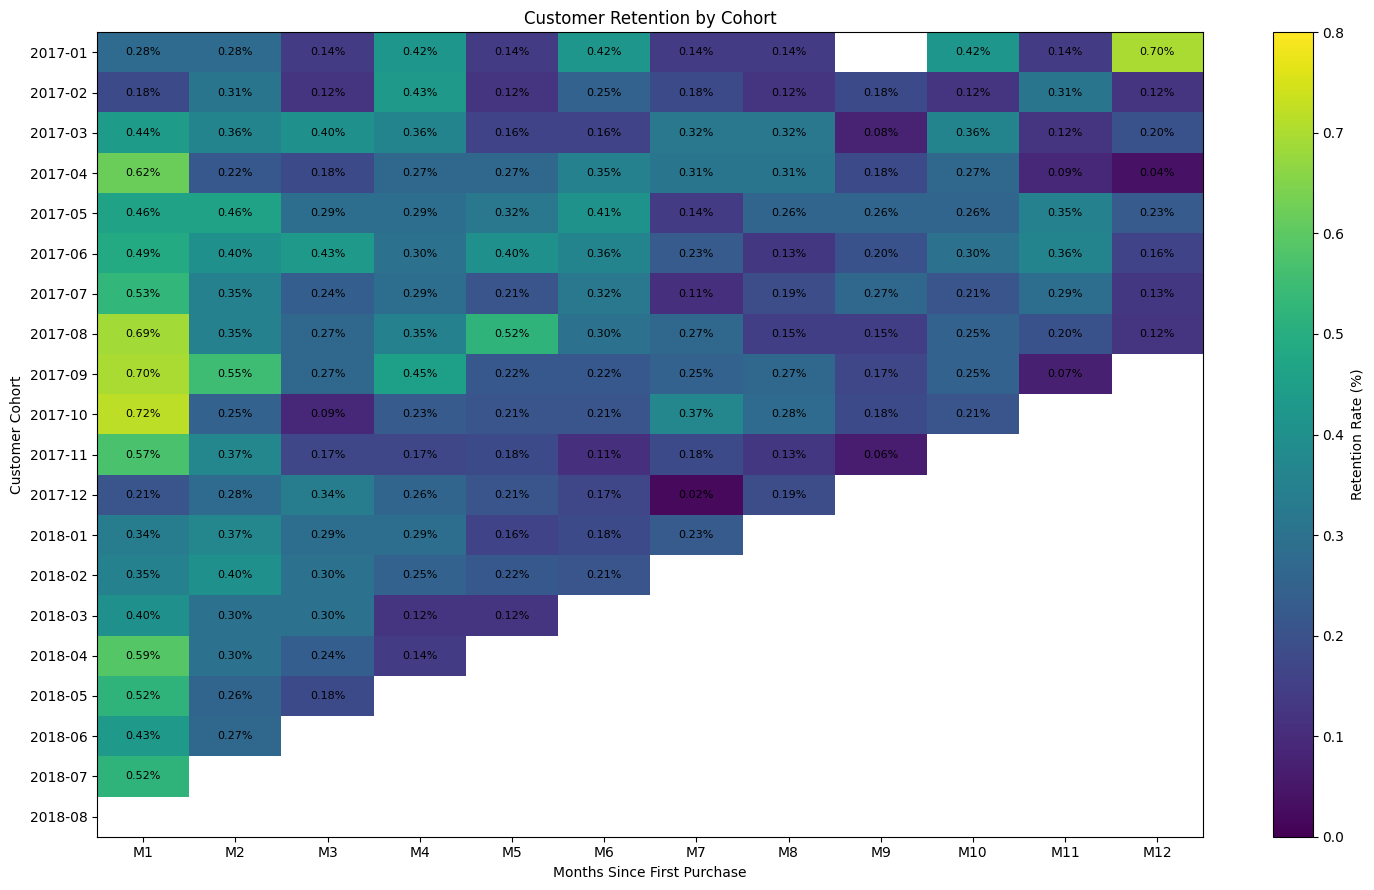

In [17]:
fig, ax = plt.subplots(figsize=(15, 9))

image = ax.imshow(
    matrix,
    aspect="auto",
    vmin=0,
    vmax=0.8
)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        value = matrix.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}%",
                ha="center",
                va="center",
                fontsize=8
            )

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels([f"M{x}" for x in matrix.columns])

ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Customer Cohort")
ax.set_title("Customer Retention by Cohort")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Retention Rate (%)")

plt.tight_layout()
plt.show()